# Confidence-Aware Adaptive XAI Model Development Pipeline

**Author:** Levy Thiga Kariuki  
**Student Number:** G20893080  
**Project:** Confidence-Aware Adaptive XAI for Financial Decision Support  
**Purpose:** This notebook documents the development pipeline behind the Streamlit artefact. It is included for reproducibility, dissertation traceability, and clear separation between model development and the deployed prototype.


## Table of Contents

1. Dataset loading and target preparation
2. Exploratory data analysis
3. Data preparation and model benchmarking
4. Model evaluation and final model selection
5. SHAP explainability development
6. Human-readable explanation generation
7. Static versus adaptive explanation logic
8. Simulated behavioural confidence dataset
9. Confidence model training and evaluation
10. Saving model artefacts for the Streamlit prototype

## Notebook Notes

- This notebook documents the research/development pipeline behind the final app artefact.
- The financial prediction model and confidence model are saved into `models/` so the Streamlit app can load stable artefacts.
- The confidence model uses simulated behavioural interaction features as a prototype signal, not real participant behavioural tracking.
- The app itself contains the polished participant-facing workflow; this notebook is retained to show how the model components were produced.


## 1. Dataset loading

Loads the German Credit dataset from UCI and converts the target to binary labels: `0 = good credit risk`, `1 = bad credit risk`.


In [ ]:
# ============================================================
# Financial Prediction Pipeline - Stage 1
# Dataset Loading + Initial EDA
# Project: Confidence-Aware Adaptive XAI for Financial Decision Support
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load German Credit Dataset
# -----------------------------

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

column_names = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "present_residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

df = pd.read_csv(url, sep=" ", names=column_names)

# In the German Credit dataset:
# 1 = good credit risk
# 2 = bad credit risk
df["target"] = df["target"].map({1: 0, 2: 1})  # 0 = good, 1 = bad

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

# -----------------------------
# Project Paths
# -----------------------------
from pathlib import Path

# Resolve project folders whether the notebook is run from the repository root
# or from inside the notebooks/ directory.
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "app.py").exists() else CURRENT_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)


Dataset loaded successfully.
Shape: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


## 2. Exploratory data analysis

Inspects class balance, feature distributions, feature-target relationships, and early modelling signals.


In [ ]:
# -----------------------------
# 2. Basic Dataset Inspection
# -----------------------------

import pandas as pd

# Ensure df is available; load if not already defined (robustness for kernel restarts)
if 'df' not in globals():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    column_names = [
        "checking_account_status", "duration_months", "credit_history", "purpose",
        "credit_amount", "savings_account", "employment_since", "installment_rate",
        "personal_status_sex", "other_debtors", "present_residence_since", "property",
        "age", "other_installment_plans", "housing", "existing_credits",
        "job", "people_liable", "telephone", "foreign_worker", "target"
    ]
    df = pd.read_csv(url, sep=" ", names=column_names)
    df["target"] = df["target"].map({1: 0, 2: 1})  # 0 = good, 1 = bad
    print("DataFrame 'df' was loaded within this cell as it was not found in the current session.")

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget distribution (%):")
print((df["target"].value_counts(normalize=True) * 100).round(2))


Dataset shape:
(1000, 21)

Column names:
['checking_account_status', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_since', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'target']

Data types:
checking_account_status    object
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_account            object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
present_residence_since     int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
existing_credits            int64
job                        object
people_

In [ ]:
# -----------------------------
# 3. Summary Statistics
# -----------------------------

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_account,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_since,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status_sex,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


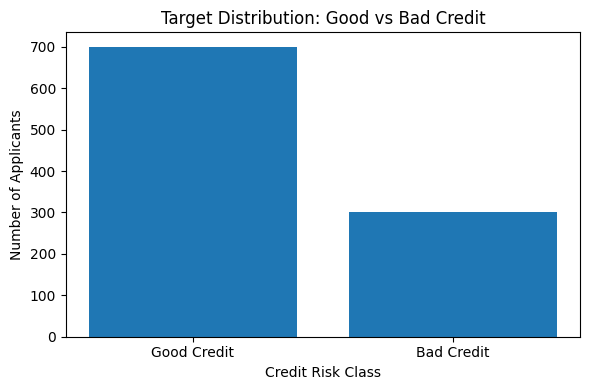

In [ ]:
# -----------------------------
# 4. Target Distribution Plot
# -----------------------------

import matplotlib.pyplot as plt

target_counts = df["target"].value_counts().sort_index()
labels = ["Good Credit", "Bad Credit"]

plt.figure(figsize=(6, 4))
plt.bar(labels, target_counts.values)
plt.title("Target Distribution: Good vs Bad Credit")
plt.xlabel("Credit Risk Class")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()


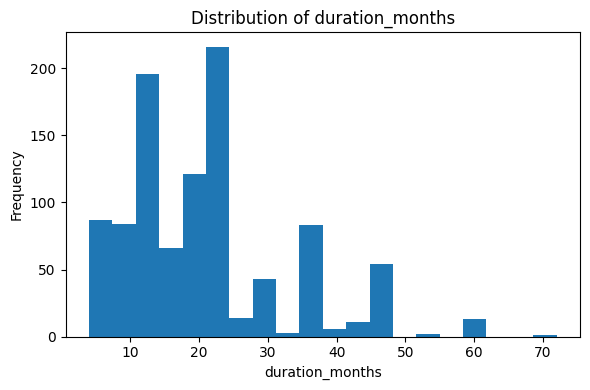

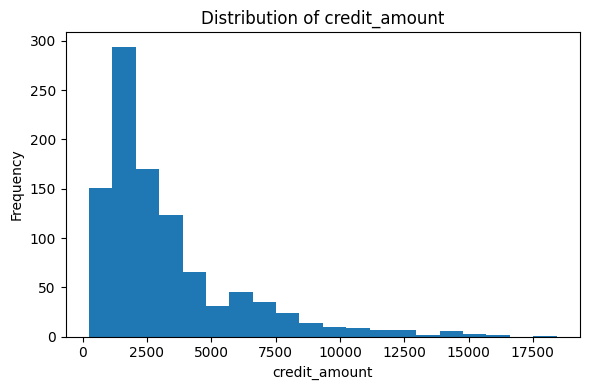

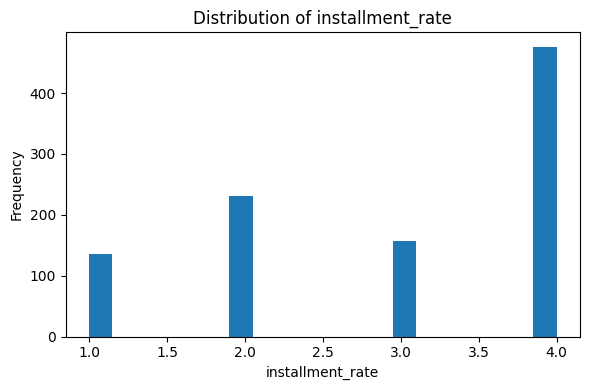

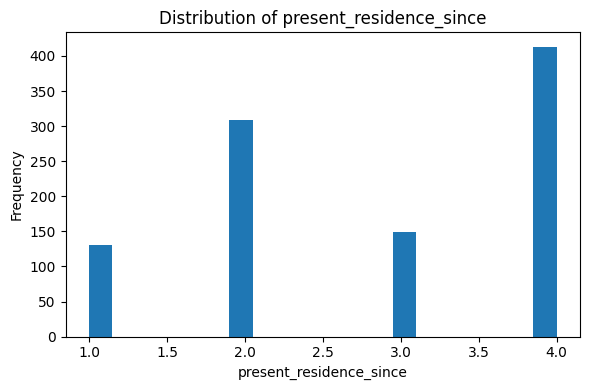

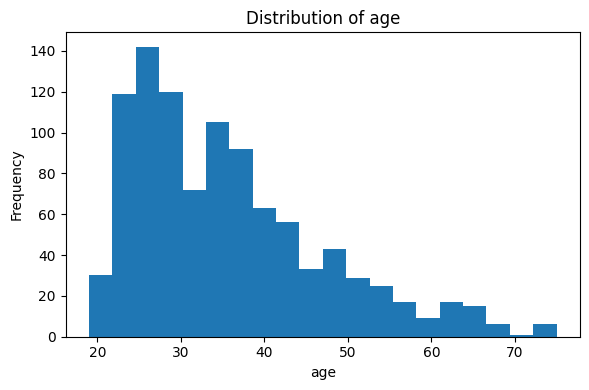

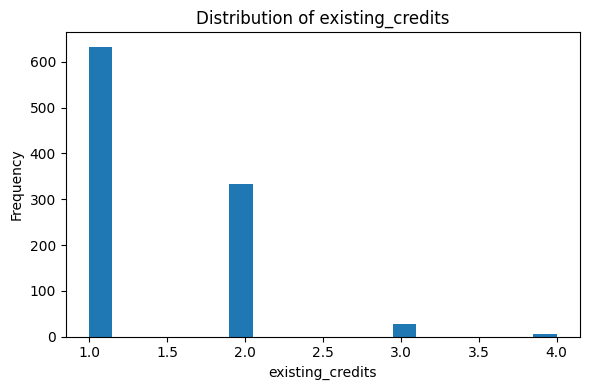

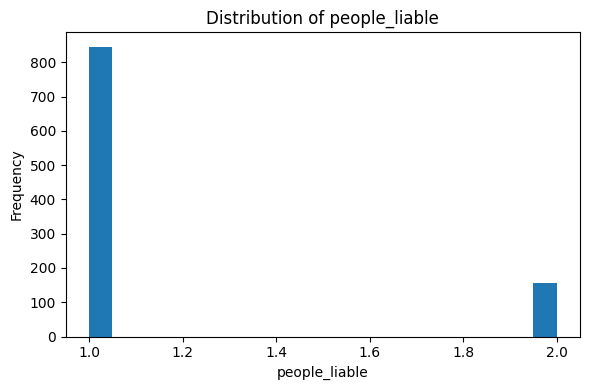

In [ ]:
# -----------------------------
# 5. Numerical Feature Distributions
# -----------------------------

numerical_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "present_residence_since",
    "age",
    "existing_credits",
    "people_liable"
]

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


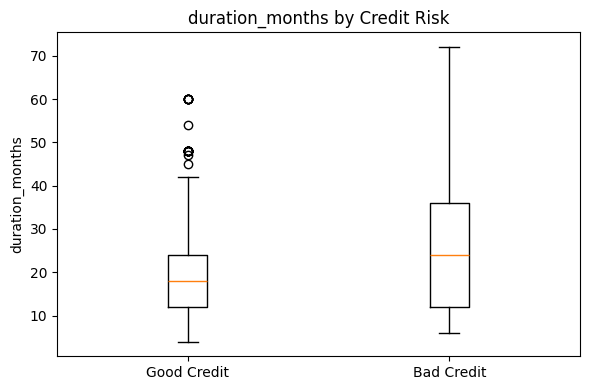

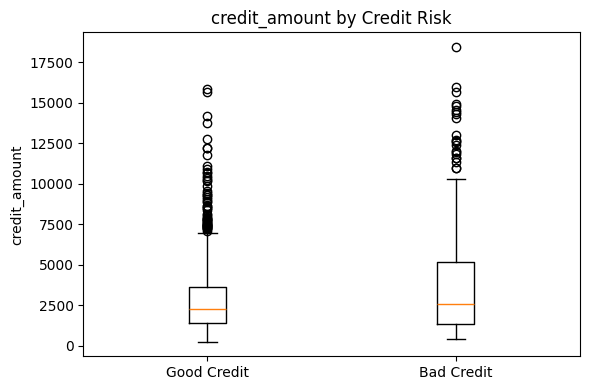

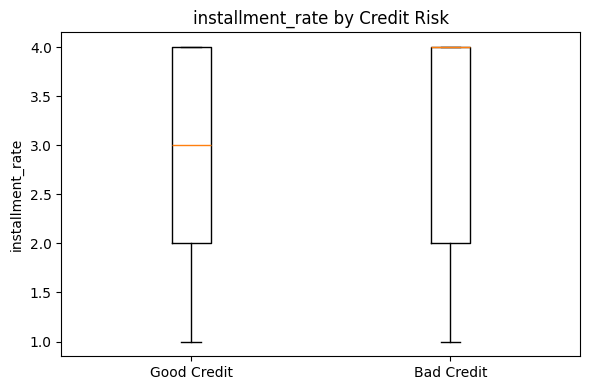

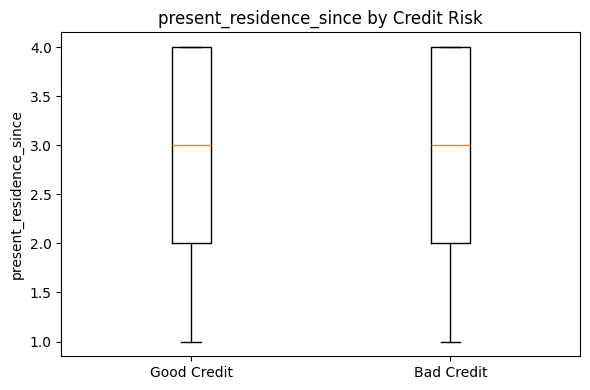

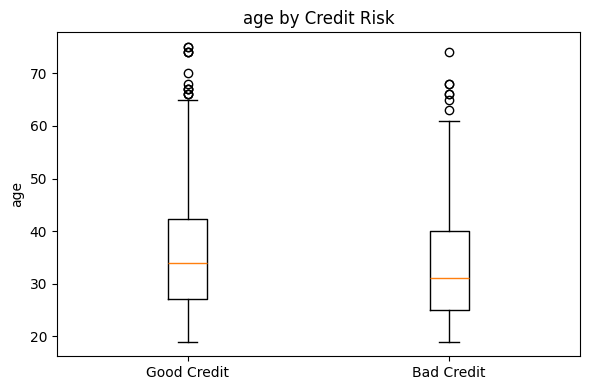

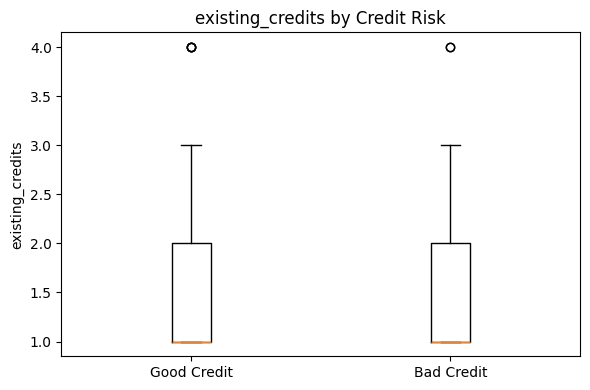

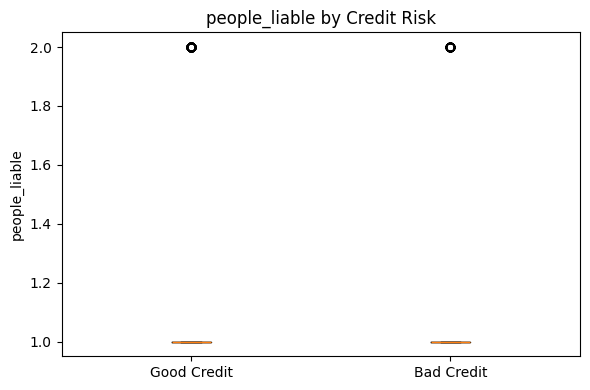

In [ ]:
# -----------------------------
# 6. Numerical Features by Target
# -----------------------------

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    data_good = df[df["target"] == 0][col]
    data_bad = df[df["target"] == 1][col]

    plt.boxplot([data_good, data_bad], tick_labels=["Good Credit", "Bad Credit"])
    plt.title(f"{col} by Credit Risk")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


In [ ]:
# -----------------------------
# 7. Categorical Feature Overview
# -----------------------------

categorical_features = [col for col in df.columns if col not in numerical_features + ["target"]]

print("Categorical features:")
print(categorical_features)

for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


Categorical features:
['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

checking_account_status
checking_account_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

credit_history
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

purpose
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

savings_account
savings_account
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

employment_since
employment_since
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64

personal_status_sex
personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

other_debtors
othe

In [ ]:
# -----------------------------
# 8. Categorical Features vs Target
# -----------------------------

for col in categorical_features:
    crosstab = pd.crosstab(df[col], df["target"], normalize="index") * 100
    print(f"\nPercentage target distribution by {col}:")
    print(crosstab.round(2))



Percentage target distribution by checking_account_status:
target                       0      1
checking_account_status              
A11                      50.73  49.27
A12                      60.97  39.03
A13                      77.78  22.22
A14                      88.32  11.68

Percentage target distribution by credit_history:
target              0      1
credit_history              
A30             37.50  62.50
A31             42.86  57.14
A32             68.11  31.89
A33             68.18  31.82
A34             82.94  17.06

Percentage target distribution by purpose:
target       0      1
purpose              
A40      61.97  38.03
A41      83.50  16.50
A410     58.33  41.67
A42      67.96  32.04
A43      77.86  22.14
A44      66.67  33.33
A45      63.64  36.36
A46      56.00  44.00
A48      88.89  11.11
A49      64.95  35.05

Percentage target distribution by savings_account:
target               0      1
savings_account              
A61              64.01  35.99
A62     

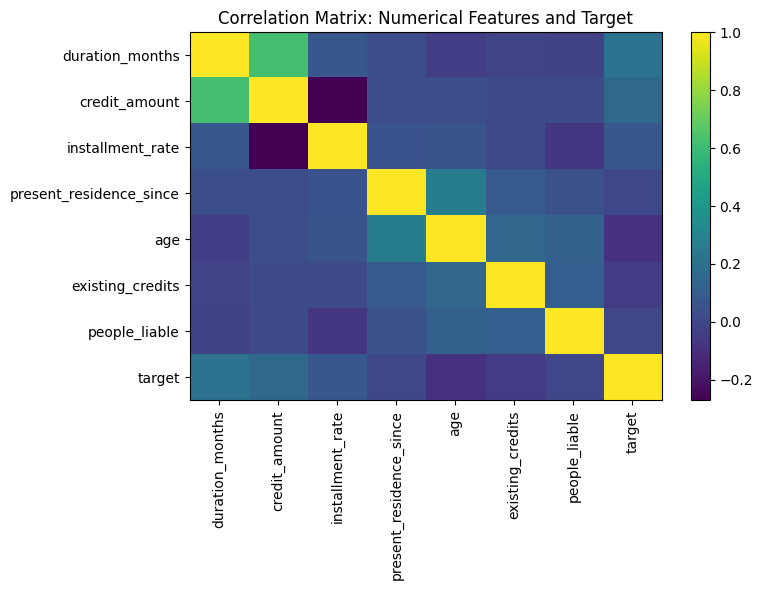

,target
target,1.000000
duration_months,0.214927
credit_amount,0.154739
installment_rate,0.072404
present_residence_since,0.002967
people_liable,-0.003015
existing_credits,-0.045732
age,-0.091127


In [ ]:
# -----------------------------
# 9. Correlation Analysis for Numerical Features
# -----------------------------

corr = df[numerical_features + ["target"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix: Numerical Features and Target")
plt.tight_layout()
plt.show()

corr["target"].sort_values(ascending=False)


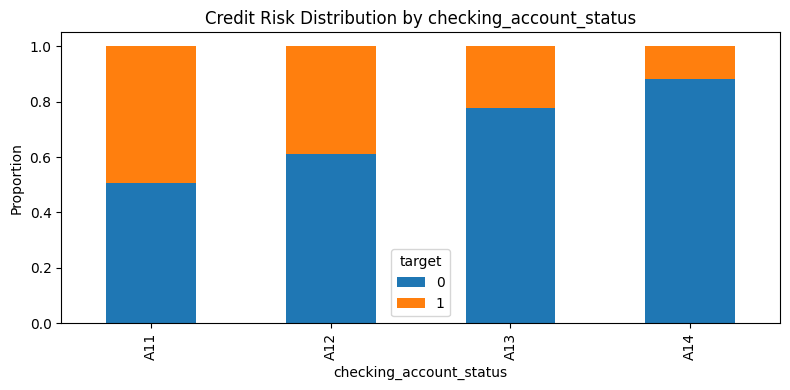

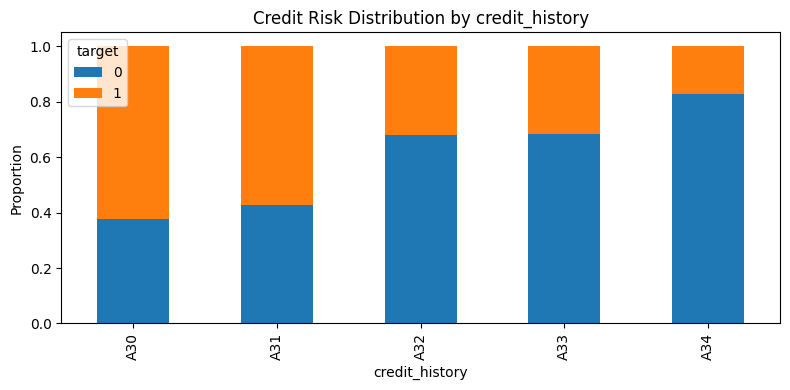

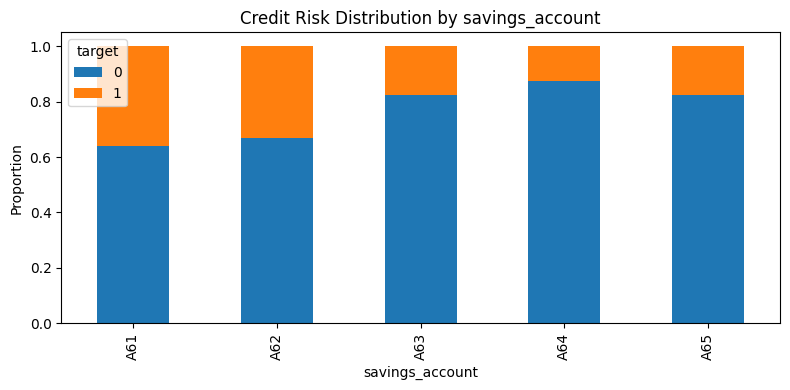

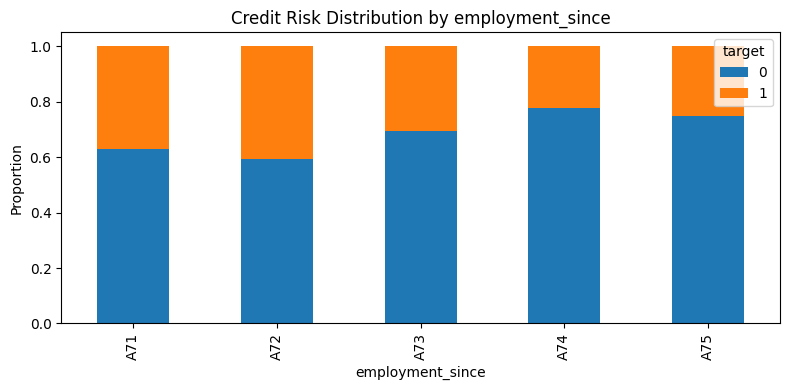

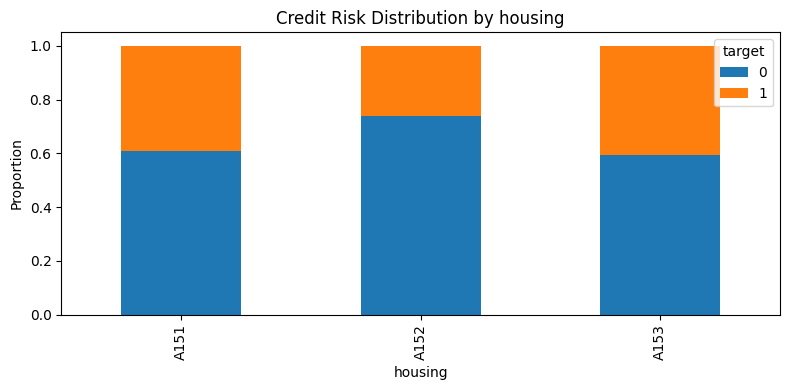

In [ ]:
# -----------------------------
# 10. Class Distribution by Important Features
# -----------------------------
important_categorical = [
    "checking_account_status",
    "credit_history",
    "savings_account",
    "employment_since",
    "housing"
]

for col in important_categorical:
    pd.crosstab(df[col], df["target"], normalize="index").plot(
        kind="bar",
        stacked=True,
        figsize=(8,4)
    )

    plt.title(f"Credit Risk Distribution by {col}")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()


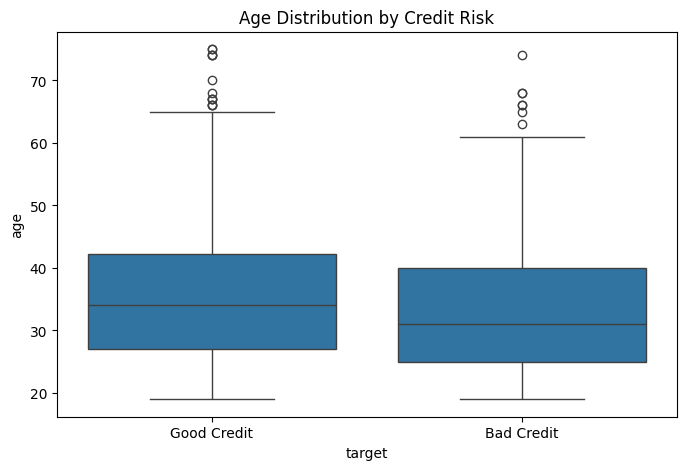

In [ ]:
# -----------------------------
# 11. Age vs Credit Risk
# -----------------------------
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="age", data=df)

plt.xticks([0,1],["Good Credit","Bad Credit"])
plt.title("Age Distribution by Credit Risk")
plt.show()


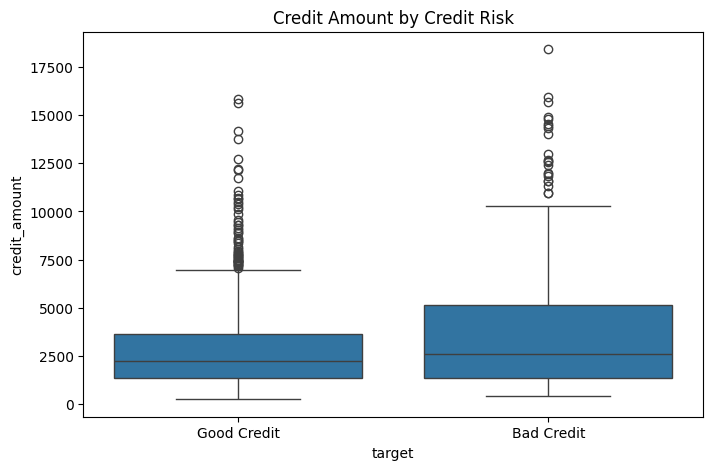

In [ ]:
# -----------------------------
# 12. Credit Amount vs Credit Risk
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="credit_amount", data=df)

plt.xticks([0,1],["Good Credit","Bad Credit"])
plt.title("Credit Amount by Credit Risk")
plt.show()


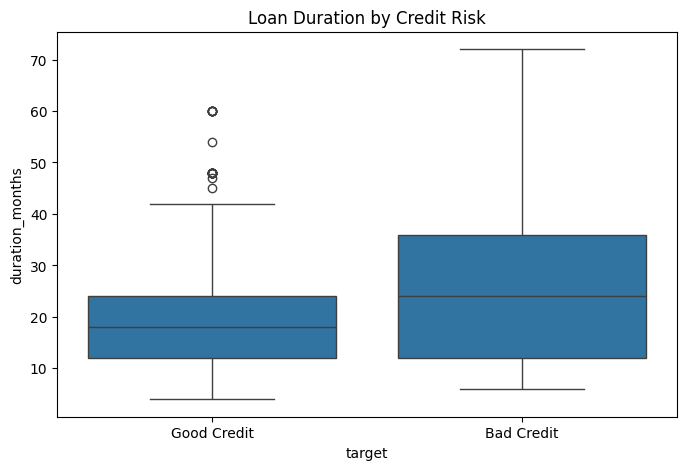

In [ ]:
# -----------------------------
# 13. Duration vs Credit Risk
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="duration_months", data=df)

plt.xticks([0,1],["Good Credit","Bad Credit"])
plt.title("Loan Duration by Credit Risk")
plt.show()


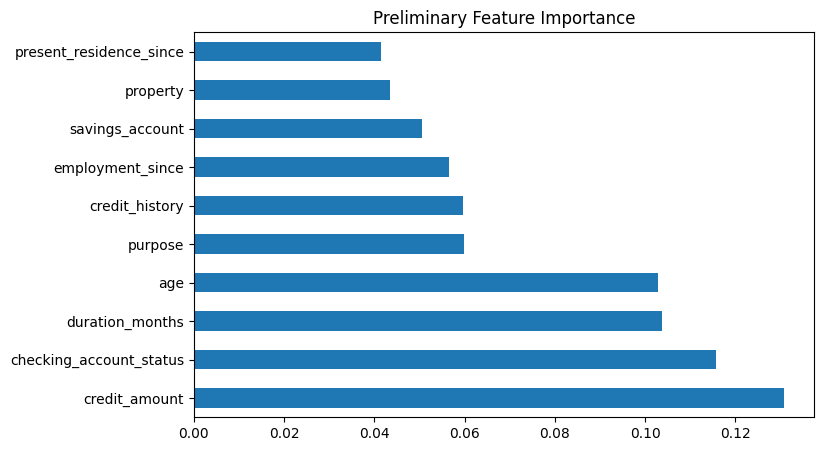

In [ ]:
# -----------------------------
# 14. Preliminary Feature Importance
# -----------------------------
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

temp_df = df.copy()

for col in temp_df.columns:
    if temp_df[col].dtype == "object":
        temp_df[col] = LabelEncoder().fit_transform(temp_df[col])

X = temp_df.drop("target", axis=1)
y = temp_df["target"]

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X,y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Preliminary Feature Importance")
plt.show()


## 3. Data preparation and model benchmarking

Encodes categorical features, creates train/test splits, scales data where needed, and compares baseline models with XGBoost.


In [ ]:
# ============================================================
# DATA PREPARATION (Encode Categorical Features)
# ============================================================

from sklearn.preprocessing import LabelEncoder

model_df = df.copy()

label_encoders = {}

for col in model_df.columns:
    if model_df[col].dtype == "object":
        le = LabelEncoder()
        model_df[col] = le.fit_transform(model_df[col])

        label_encoders[col] = le

print("Encoding complete.")
model_df.head()


Encoding complete.


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,0
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,1
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,0
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,0
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,1


In [ ]:
# -----------------------------
# Create Features and Target
# -----------------------------
X = model_df.drop("target", axis=1)
y = model_df["target"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (1000, 20)
y Shape: (1000,)


In [ ]:
# -----------------------------
# Train/Test Split
# -----------------------------

# stratified split because of the 70/30 class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 800
Testing samples: 200


In [ ]:
# -----------------------------
# Scale Data For Logistic Regression
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# -----------------------------
# Train Logistic Regression
# -----------------------------
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print("Logistic Regression trained.")


Logistic Regression trained.


In [ ]:
# -----------------------------
# Evaluate Logistic Regression
# -----------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", round(accuracy_score(y_test, lr_predictions),4))
print("Precision:", round(precision_score(y_test, lr_predictions),4))
print("Recall:", round(recall_score(y_test, lr_predictions),4))
print("F1:", round(f1_score(y_test, lr_predictions),4))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_probs),4))


Accuracy: 0.765
Precision: 0.6275
Recall: 0.5333
F1: 0.5766
ROC-AUC: 0.7905


In [ ]:
# -----------------------------
# Train Random Forest
# -----------------------------
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:,1]

print("Random Forest trained.")


Random Forest trained.


In [ ]:
# -----------------------------
# Evaluate Random Forest
# -----------------------------
print("Accuracy:", round(accuracy_score(y_test, rf_predictions),4))
print("Precision:", round(precision_score(y_test, rf_predictions),4))
print("Recall:", round(recall_score(y_test, rf_predictions),4))
print("F1:", round(f1_score(y_test, rf_predictions),4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_probs),4))


Accuracy: 0.77
Precision: 0.7059
Recall: 0.4
F1: 0.5106
ROC-AUC: 0.7989


In [ ]:
# -----------------------------
# Install XGboost
# -----------------------------
# If running in a fresh notebook environment, uncomment the next line.
# %pip install xgboost


In [ ]:
# -----------------------------
# Train XGBoost
# -----------------------------
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost trained.")


XGBoost trained.


In [ ]:
# -----------------------------
# Evaluate XGBoost
# -----------------------------
print("Accuracy:", round(accuracy_score(y_test, xgb_predictions),4))
print("Precision:", round(precision_score(y_test, xgb_predictions),4))
print("Recall:", round(recall_score(y_test, xgb_predictions),4))
print("F1:", round(f1_score(y_test, xgb_predictions),4))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_probs),4))


Accuracy: 0.78
Precision: 0.6818
Recall: 0.5
F1: 0.5769
ROC-AUC: 0.7875


## 4. Model evaluation

Compares candidate models using test-set metrics, confusion matrices, ROC/PR curves, feature importance, and cross-validation.


In [ ]:
# -----------------------------
# Comparison Table
# -----------------------------
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "F1": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

results.sort_values("ROC_AUC", ascending=False)


,Model,Accuracy,F1,ROC_AUC
1,Random Forest,0.770,0.510638,0.798929
0,Logistic Regression,0.765,0.576577,0.790476
2,XGBoost,0.780,0.576923,0.787500


<Figure size 500x500 with 0 Axes>

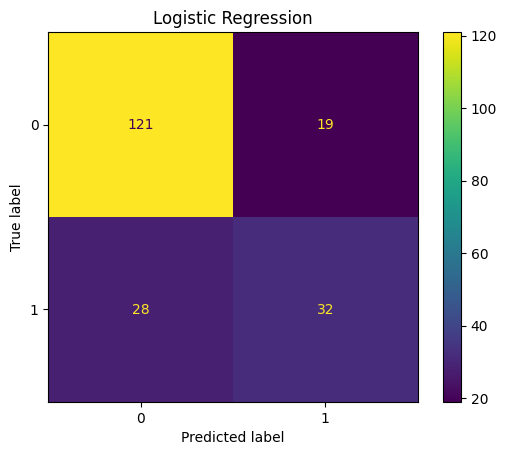

<Figure size 500x500 with 0 Axes>

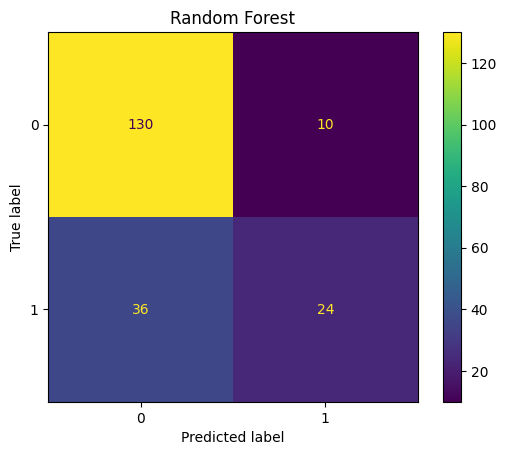

<Figure size 500x500 with 0 Axes>

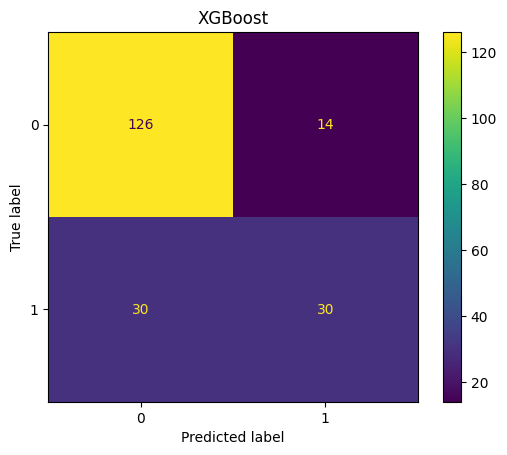

In [ ]:
# -----------------------------
# Confusion Matrices
# -----------------------------
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

for name, (model, X_eval) in models.items():

    plt.figure(figsize=(5,5))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_eval,
        y_test
    )

    plt.title(name)
    plt.show()


In [ ]:
# -----------------------------
# Classification Reports
# -----------------------------
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_predictions))

print("\nRandom Forest")
print(classification_report(y_test, rf_predictions))

print("\nXGBoost")
print(classification_report(y_test, xgb_predictions))


Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       140
           1       0.63      0.53      0.58        60

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200


Random Forest
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       140
           1       0.71      0.40      0.51        60

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200


XGBoost
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       140
           1       0.68      0.50      0.58        60

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0

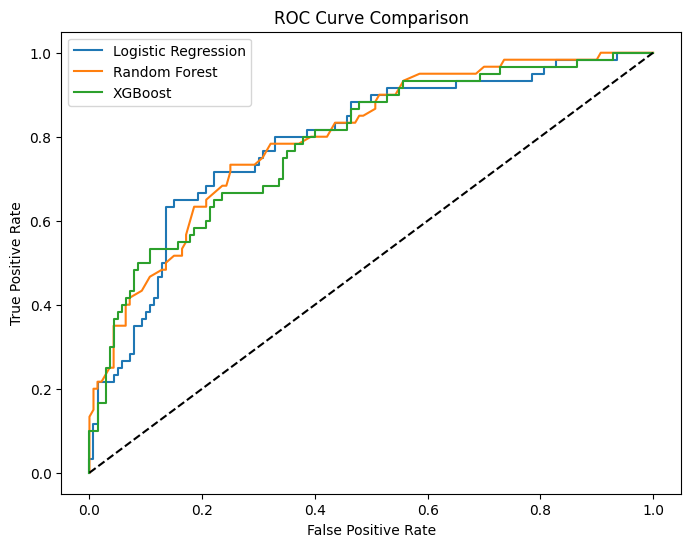

In [ ]:
# -----------------------------
# ROC Curve Comparison
# -----------------------------
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


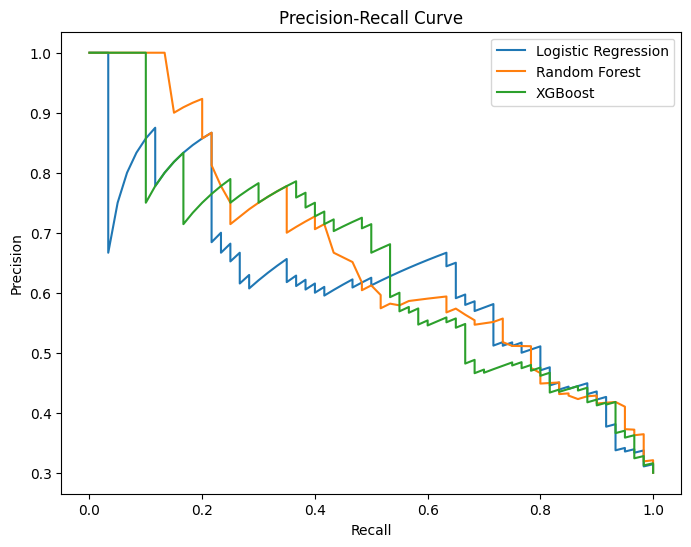

In [ ]:
# -----------------------------
# Precision-Recall Curve
# -----------------------------
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_probs)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")
plt.plot(xgb_recall, xgb_precision, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


Top 10 Random Forest Features:


,Feature,Random Forest Importance
4,credit_amount,0.134261
0,checking_account_status,0.106517
12,age,0.102290
1,duration_months,0.095338
3,purpose,0.057907
2,credit_history,0.057013
6,employment_since,0.053743
5,savings_account,0.050950
11,property,0.049030
7,installment_rate,0.044800



Top 10 XGBoost Features:


,Feature,XGBoost Importance
0,checking_account_status,0.153387
9,other_debtors,0.082952
5,savings_account,0.061083
2,credit_history,0.059271
13,other_installment_plans,0.057098
1,duration_months,0.047371
11,property,0.044835
19,foreign_worker,0.044424
6,employment_since,0.043468
14,housing,0.043405


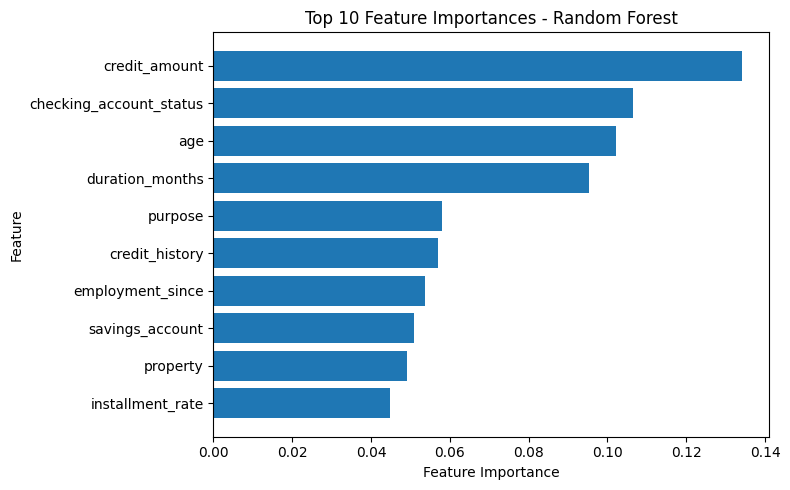

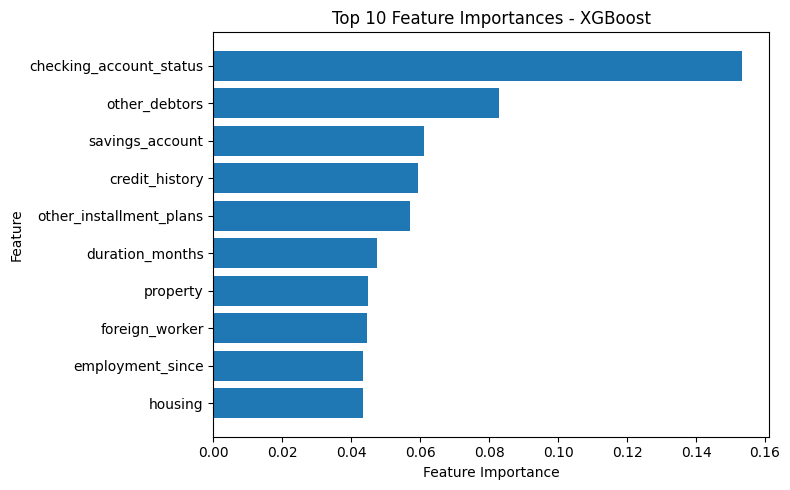

In [ ]:
# -----------------------------
# Feature Importance Comparison
# Random Forest vs XGBoost
# -----------------------------

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest Importance": rf_model.feature_importances_,
    "XGBoost Importance": xgb_model.feature_importances_
})

# Sort separately for each model
rf_top10 = feature_importance_df.sort_values(
    by="Random Forest Importance",
    ascending=False
).head(10)

xgb_top10 = feature_importance_df.sort_values(
    by="XGBoost Importance",
    ascending=False
).head(10)

# Display top 10 tables
print("Top 10 Random Forest Features:")
display(rf_top10[["Feature", "Random Forest Importance"]])

print("\nTop 10 XGBoost Features:")
display(xgb_top10[["Feature", "XGBoost Importance"]])

# Plot Random Forest feature importance
plt.figure(figsize=(8, 5))
plt.barh(
    rf_top10["Feature"][::-1],
    rf_top10["Random Forest Importance"][::-1]
)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Plot XGBoost feature importance
plt.figure(figsize=(8, 5))
plt.barh(
    xgb_top10["Feature"][::-1],
    xgb_top10["XGBoost Importance"][::-1]
)
plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# 5-Fold Cross-Validation Comparison
# Logistic Regression vs Random Forest vs XGBoost
# -----------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Stratified CV keeps the good/bad credit class balance in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define models
# Logistic Regression uses scaling inside a pipeline.
# Random Forest and XGBoost do not require scaling.
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": model_name,
        "CV ROC-AUC Scores": np.round(scores, 4),
        "Mean ROC-AUC": scores.mean(),
        "Std Dev": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

# Sort by Mean ROC-AUC
cv_results_df = cv_results_df.sort_values(
    by="Mean ROC-AUC",
    ascending=False
)

display(cv_results_df)

print("Best model based on cross-validated ROC-AUC:")
print(cv_results_df.iloc[0]["Model"])


,Model,CV ROC-AUC Scores,Mean ROC-AUC,Std Dev
1,Random Forest,"[0.8135, 0.7803, 0.7774, 0.8248, 0.8064]",0.800464,0.018605
0,Logistic Regression,"[0.7892, 0.7483, 0.7781, 0.8042, 0.7954]",0.783024,0.019311
2,XGBoost,"[0.7783, 0.739, 0.7598, 0.79, 0.815]",0.776429,0.025887


Best model based on cross-validated ROC-AUC:
Random Forest


In [ ]:
# -----------------------------
# Final Model Comparison Table
# Test Set Metrics + Cross-Validation
# -----------------------------

test_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "Test F1": [
        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

final_comparison = test_results.merge(
    cv_results_df[["Model", "Mean ROC-AUC", "Std Dev"]],
    on="Model",
    how="left"
)

final_comparison = final_comparison.sort_values(
    by=["Test F1", "Test Accuracy", "Test ROC-AUC"],
    ascending=False
)

display(final_comparison)

print("Chosen final model: XGBoost")
print("Reason: XGBoost achieved the highest test accuracy and joint-highest F1-score, while maintaining competitive ROC-AUC performance.")


,Model,Test Accuracy,Test F1,Test ROC-AUC,Mean ROC-AUC,Std Dev
2,XGBoost,0.780,0.576923,0.787500,0.776429,0.025887
0,Logistic Regression,0.765,0.576577,0.790476,0.783024,0.019311
1,Random Forest,0.770,0.510638,0.798929,0.800464,0.018605


Chosen final model: XGBoost
Reason: XGBoost achieved the highest test accuracy and joint-highest F1-score, while maintaining competitive ROC-AUC performance.


In [ ]:
# -----------------------------
# Save model
# -----------------------------
import joblib

# Ensure final_model is defined before saving
final_model = xgb_model

joblib.dump(final_model, MODELS_DIR / "xgboost_credit_model.pkl")
joblib.dump(label_encoders, MODELS_DIR / "label_encoders.pkl")


['label_encoders.pkl']

## 5. SHAP explainability

Develops global and local explanation views for the selected XGBoost credit-risk model.


In [ ]:
# -----------------------------
# Install and Import SHAP
# -----------------------------

# If running in a fresh notebook environment, uncomment the next line.
# %pip install shap

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("SHAP version:", shap.__version__)


SHAP version: 0.51.0


In [ ]:
# -----------------------------
# Create SHAP Explainer for XGBoost
# -----------------------------

# XGBoost was selected as the final financial prediction model
final_model = xgb_model

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values generated.")
print("Shape of SHAP values:", np.array(shap_values).shape)


SHAP values generated.
Shape of SHAP values: (200, 20)


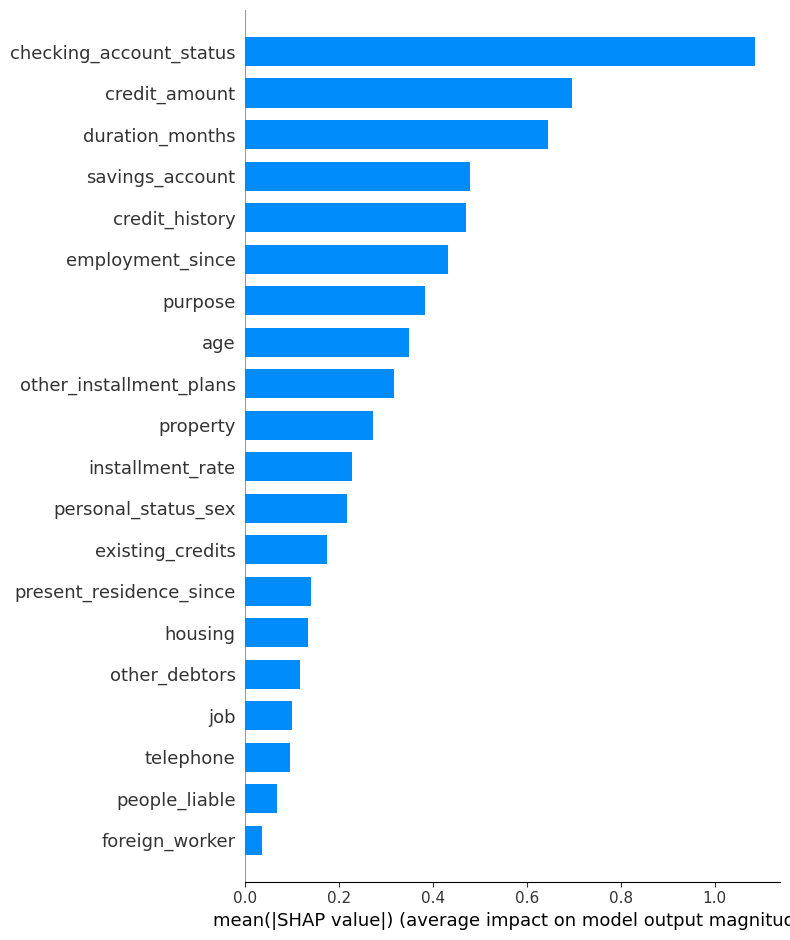

In [ ]:
# -----------------------------
# Global SHAP Summary Plot
# -----------------------------

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


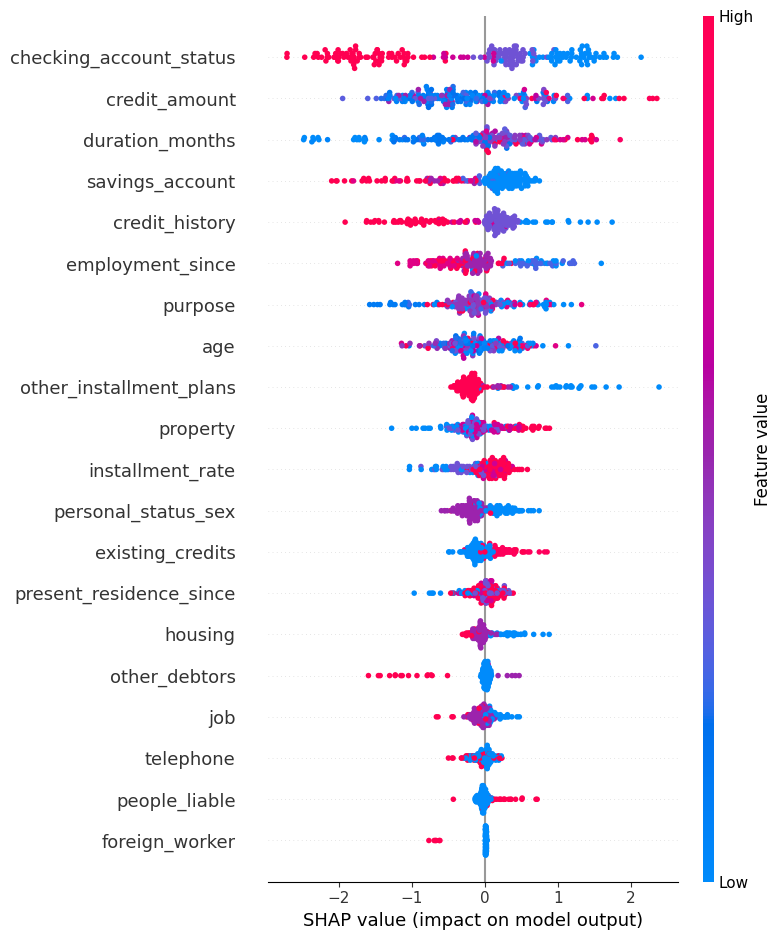

In [ ]:
# -----------------------------
# Detailed SHAP Summary Plot
# -----------------------------

shap.summary_plot(
    shap_values,
    X_test
)


Prediction: Good Credit
Probability of Bad Credit: 0.1686


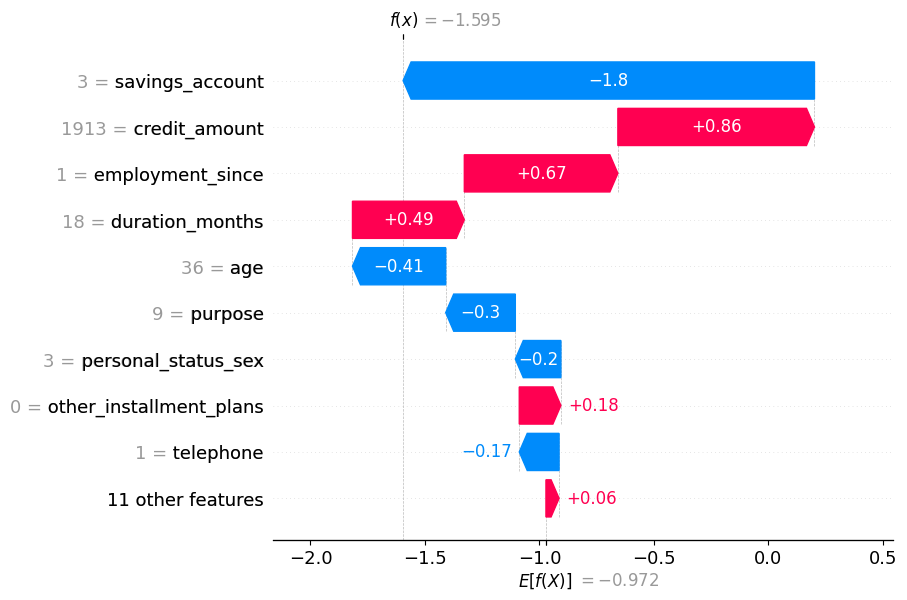

In [ ]:
# -----------------------------
# Static SHAP Waterfall Plot for One Applicant
# -----------------------------

sample_index = 0

sample = X_test.iloc[[sample_index]]

prediction = final_model.predict(sample)[0]
prediction_probability = final_model.predict_proba(sample)[0][1]

print("Prediction:", "Bad Credit" if prediction == 1 else "Good Credit")
print("Probability of Bad Credit:", round(prediction_probability, 4))

# Create SHAP Explanation object
sample_explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=sample.iloc[0],
    feature_names=X_test.columns
)

shap.plots.waterfall(sample_explanation, max_display=10)


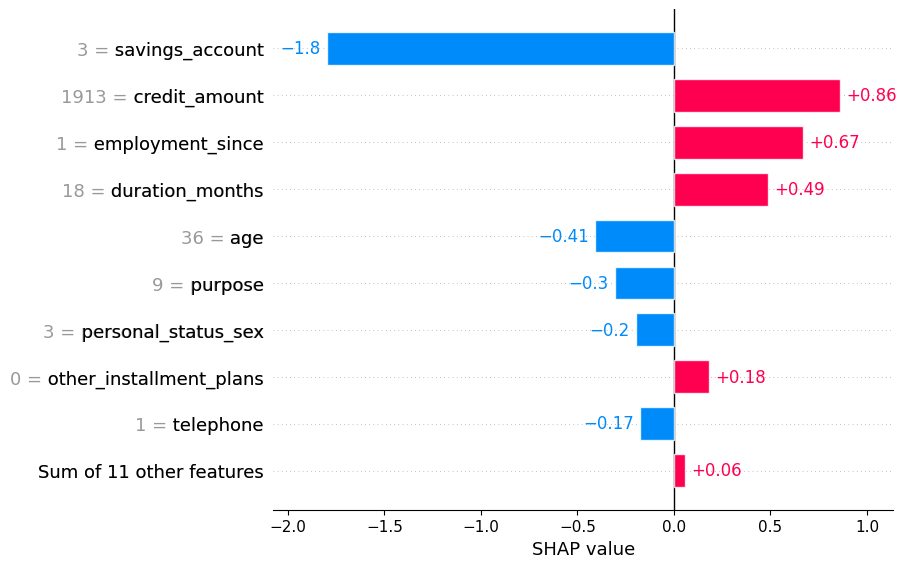

In [ ]:
# -----------------------------
# Static Local SHAP Bar Plot for One Applicant
# -----------------------------

shap.plots.bar(sample_explanation, max_display=10)


In [ ]:
# -----------------------------
# Local SHAP Explanation Table
# -----------------------------

def get_local_shap_table(sample_index, X_data, shap_values, top_n=10):
    shap_row = shap_values[sample_index]

    local_df = pd.DataFrame({
        "Feature": X_data.columns,
        "Feature Value": X_data.iloc[sample_index].values,
        "SHAP Value": shap_row,
        "Absolute Impact": np.abs(shap_row)
    })

    local_df = local_df.sort_values(
        by="Absolute Impact",
        ascending=False
    )

    return local_df.head(top_n)

local_explanation_table = get_local_shap_table(
    sample_index=sample_index,
    X_data=X_test,
    shap_values=shap_values,
    top_n=10
)

local_explanation_table


,Feature,Feature Value,SHAP Value,Absolute Impact
5,savings_account,3,-1.796361,1.796361
4,credit_amount,1913,0.858554,0.858554
6,employment_since,1,0.670587,0.670587
1,duration_months,18,0.488396,0.488396
12,age,36,-0.407102,0.407102
3,purpose,9,-0.304054,0.304054
8,personal_status_sex,3,-0.198995,0.198995
13,other_installment_plans,0,0.181820,0.181820
18,telephone,1,-0.173865,0.173865
7,installment_rate,3,0.134978,0.134978


In [ ]:
# -----------------------------
# Generate Text Explanation from SHAP Values
# -----------------------------

def generate_text_explanation(sample_index, X_data, shap_values, top_n=5):
    local_df = get_local_shap_table(
        sample_index=sample_index,
        X_data=X_data,
        shap_values=shap_values,
        top_n=top_n
    )

    explanation_lines = []

    for _, row in local_df.iterrows():
        direction = "increased risk" if row["SHAP Value"] > 0 else "reduced risk"

        explanation_lines.append(
            f"{row['Feature']} = {row['Feature Value']} {direction} "
            f"(impact: {row['SHAP Value']:.3f})"
        )

    return explanation_lines

text_explanation = generate_text_explanation(
    sample_index=sample_index,
    X_data=X_test,
    shap_values=shap_values,
    top_n=5
)

for line in text_explanation:
    print("-", line)


- savings_account = 3 reduced risk (impact: -1.796)
- credit_amount = 1913 increased risk (impact: 0.859)
- employment_since = 1 increased risk (impact: 0.671)
- duration_months = 18 increased risk (impact: 0.488)
- age = 36 reduced risk (impact: -0.407)


In [ ]:
# -----------------------------
# Extract Top SHAP Features for One Applicant
# -----------------------------

def get_top_shap_features(sample_index, X_data, shap_values, top_n=5):
    feature_names = X_data.columns
    shap_row = shap_values[sample_index]

    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "Feature Value": X_data.iloc[sample_index].values,
        "SHAP Value": shap_row,
        "Absolute Impact": np.abs(shap_row)
    })

    explanation_df = explanation_df.sort_values(
        by="Absolute Impact",
        ascending=False
    )

    return explanation_df.head(top_n)

# Example: top 5 SHAP features for applicant 0
top_features = get_top_shap_features(
    sample_index=0,
    X_data=X_test,
    shap_values=shap_values,
    top_n=5
)

top_features


,Feature,Feature Value,SHAP Value,Absolute Impact
5,savings_account,3,-1.796361,1.796361
4,credit_amount,1913,0.858554,0.858554
6,employment_since,1,0.670587,0.670587
1,duration_months,18,0.488396,0.488396
12,age,36,-0.407102,0.407102


In [ ]:
# -----------------------------
# Find One Good Credit and One Bad Credit Example
# -----------------------------

# Reset indices to make SHAP indexing easier
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Get first good and bad applicant in the test set
good_index = y_test_reset[y_test_reset == 0].index[0]
bad_index = y_test_reset[y_test_reset == 1].index[0]

print("Good applicant index:", good_index)
print("Bad applicant index:", bad_index)

print("\nGood applicant actual class:", y_test_reset.iloc[good_index])
print("Bad applicant actual class:", y_test_reset.iloc[bad_index])


Good applicant index: 0
Bad applicant index: 2

Good applicant actual class: 0
Bad applicant actual class: 1


In [ ]:
# -----------------------------
# SHAP Explanation Helper Function
# -----------------------------

def explain_applicant(sample_index, X_data, y_data, model, explainer, shap_values, top_n=5):
    sample = X_data.iloc[[sample_index]]

    prediction = model.predict(sample)[0]
    probability_bad = model.predict_proba(sample)[0][1]
    probability_good = model.predict_proba(sample)[0][0]

    actual = y_data.iloc[sample_index]

    print("=" * 60)
    print(f"Applicant Index: {sample_index}")
    print(f"Actual Class: {'Bad Credit' if actual == 1 else 'Good Credit'}")
    print(f"Predicted Class: {'Bad Credit' if prediction == 1 else 'Good Credit'}")
    print(f"Probability of Good Credit: {probability_good:.4f}")
    print(f"Probability of Bad Credit: {probability_bad:.4f}")
    print("=" * 60)

    # Create local explanation table
    local_df = pd.DataFrame({
        "Feature": X_data.columns,
        "Feature Value": X_data.iloc[sample_index].values,
        "SHAP Value": shap_values[sample_index],
        "Absolute Impact": np.abs(shap_values[sample_index])
    }).sort_values(by="Absolute Impact", ascending=False)

    display(local_df.head(top_n))

    print("\nText Explanation:")
    for _, row in local_df.head(top_n).iterrows():
        direction = "increased risk" if row["SHAP Value"] > 0 else "reduced risk"
        print(
            f"- {row['Feature']} = {row['Feature Value']} {direction} "
            f"(impact: {row['SHAP Value']:.3f})"
        )

    # Waterfall plot
    sample_explanation = shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_data.iloc[sample_index],
        feature_names=X_data.columns
    )

    shap.plots.waterfall(sample_explanation, max_display=10)


Applicant Index: 0
Actual Class: Good Credit
Predicted Class: Good Credit
Probability of Good Credit: 0.8314
Probability of Bad Credit: 0.1686


,Feature,Feature Value,SHAP Value,Absolute Impact
5,savings_account,3,-1.796361,1.796361
4,credit_amount,1913,0.858554,0.858554
6,employment_since,1,0.670587,0.670587
1,duration_months,18,0.488396,0.488396
12,age,36,-0.407102,0.407102



Text Explanation:
- savings_account = 3 reduced risk (impact: -1.796)
- credit_amount = 1913 increased risk (impact: 0.859)
- employment_since = 1 increased risk (impact: 0.671)
- duration_months = 18 increased risk (impact: 0.488)
- age = 36 reduced risk (impact: -0.407)


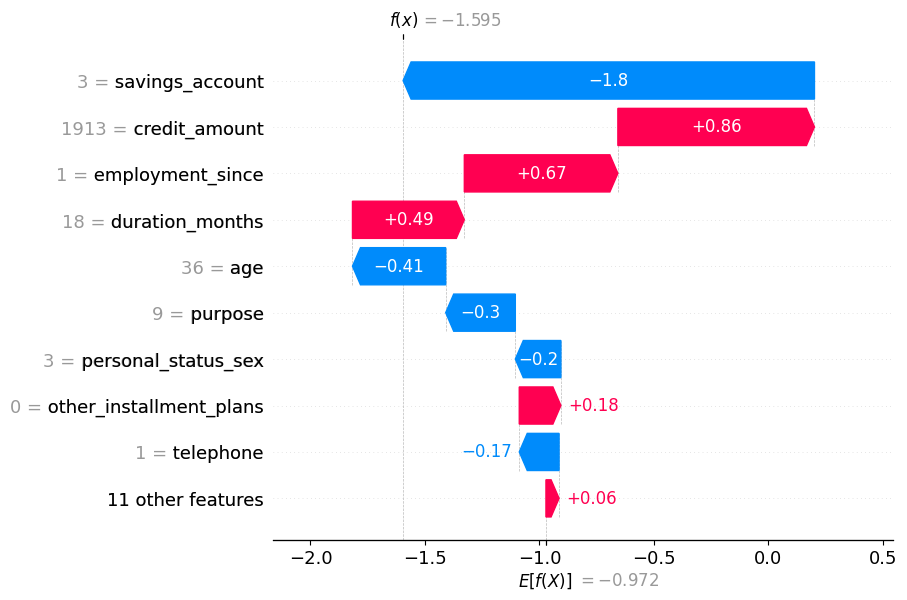

In [ ]:
# -----------------------------
# Explain Good Credit Applicant
# -----------------------------

explain_applicant(
    sample_index=good_index,
    X_data=X_test_reset,
    y_data=y_test_reset,
    model=final_model,
    explainer=explainer,
    shap_values=shap_values,
    top_n=5
)


Applicant Index: 2
Actual Class: Bad Credit
Predicted Class: Bad Credit
Probability of Good Credit: 0.0458
Probability of Bad Credit: 0.9542


,Feature,Feature Value,SHAP Value,Absolute Impact
0,checking_account_status,0,1.665499,1.665499
1,duration_months,24,0.968892,0.968892
6,employment_since,1,0.517671,0.517671
11,property,0,-0.504464,0.504464
4,credit_amount,1024,-0.454825,0.454825



Text Explanation:
- checking_account_status = 0 increased risk (impact: 1.665)
- duration_months = 24 increased risk (impact: 0.969)
- employment_since = 1 increased risk (impact: 0.518)
- property = 0 reduced risk (impact: -0.504)
- credit_amount = 1024 reduced risk (impact: -0.455)


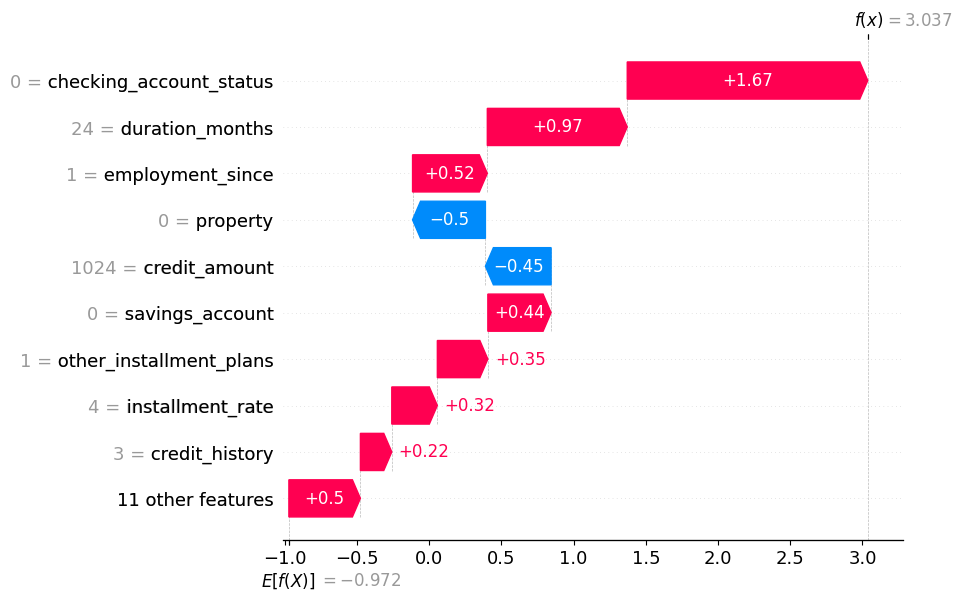

In [ ]:
# -----------------------------
# Explain Bad Credit Applicant
# -----------------------------

explain_applicant(
    sample_index=bad_index,
    X_data=X_test_reset,
    y_data=y_test_reset,
    model=final_model,
    explainer=explainer,
    shap_values=shap_values,
    top_n=5
)


In [ ]:
# -----------------------------
# Human-Readable Feature and Value Mappings
# User-facing labels use approximate modern GBP-equivalent wording.
# The underlying dataset values are NOT changed.
# -----------------------------

feature_name_map = {
    "checking_account_status": "Checking account status",
    "duration_months": "Loan duration",
    "credit_history": "Credit history",
    "purpose": "Loan purpose",
    "credit_amount": "Credit amount",
    "savings_account": "Savings account status",
    "employment_since": "Employment duration",
    "installment_rate": "Instalment rate",
    "personal_status_sex": "Personal status / sex",
    "other_debtors": "Other debtors or guarantors",
    "present_residence_since": "Years at current residence",
    "property": "Property status",
    "age": "Age",
    "other_installment_plans": "Other instalment plans",
    "housing": "Housing status",
    "existing_credits": "Number of existing credits",
    "job": "Job type",
    "people_liable": "Number of dependants",
    "telephone": "Telephone registered",
    "foreign_worker": "Foreign worker status"
}

# Approximate explanation-only conversion:
# 1 DM in the historical dataset is treated as roughly £0.75 in modern user-facing labels.
# This is NOT used for modelling, only for explanation readability.
DM_TO_GBP_APPROX = 0.75

def dm_to_gbp_label(amount):
    gbp_amount = amount * DM_TO_GBP_APPROX
    return f"approx. £{gbp_amount:,.0f}"

value_maps = {
    "checking_account_status": {
        "A11": "Negative balance (less than approx. £0)",
        "A12": "Low positive balance (approx. £0 to £150)",
        "A13": "Strong positive balance (greater than or equal to approx. £150)",
        "A14": "No checking account"
    },
    "credit_history": {
        "A30": "no credits taken / all credits paid back duly",
        "A31": "all credits at this bank paid back duly",
        "A32": "existing credits paid back duly until now",
        "A33": "delay in paying off in the past",
        "A34": "critical account / other credits existing"
    },
    "purpose": {
        "A40": "car (new)",
        "A41": "car (used)",
        "A42": "furniture/equipment",
        "A43": "radio/television",
        "A44": "domestic appliances",
        "A45": "repairs",
        "A46": "education",
        "A47": "vacation",
        "A48": "retraining",
        "A49": "business",
        "A410": "others"
    },
    "savings_account": {
        "A61": "Low savings (less than approx. £75)",
        "A62": "Moderate savings (approx. £75 to £375)",
        "A63": "High savings (approx. £375 to £750)",
        "A64": "Very high savings (greater than or equal to approx. £750)",
        "A65": "No savings information"
    },
    "employment_since": {
        "A71": "unemployed",
        "A72": "less than 1 year",
        "A73": "1 to 4 years",
        "A74": "4 to 7 years",
        "A75": "greater than 7 years"
    },
    "personal_status_sex": {
        "A91": "male divorced/separated",
        "A92": "female divorced/separated/married",
        "A93": "male single",
        "A94": "male married/widowed",
        "A95": "female single"
    },
    "other_debtors": {
        "A101": "none",
        "A102": "co-applicant",
        "A103": "guarantor"
    },
    "property": {
        "A121": "real estate",
        "A122": "building society savings agreement / life insurance",
        "A123": "car or other property",
        "A124": "unknown / no property"
    },
    "other_installment_plans": {
        "A141": "bank",
        "A142": "stores",
        "A143": "none"
    },
    "housing": {
        "A151": "rent",
        "A152": "own",
        "A153": "for free"
    },
    "job": {
        "A171": "unemployed / unskilled non-resident",
        "A172": "unskilled resident",
        "A173": "skilled employee / official",
        "A174": "management / self-employed / highly qualified"
    },
    "telephone": {
        "A191": "none",
        "A192": "yes, registered"
    },
    "foreign_worker": {
        "A201": "yes",
        "A202": "no"
    }
}

print("Feature and value mappings created with approximate GBP-equivalent user-facing labels.")


Feature and value mappings created with approximate GBP-equivalent user-facing labels.


In [ ]:
# -----------------------------
# Decode Encoded Feature Values with Human-Readable Units
# -----------------------------

def decode_feature_value(feature, encoded_value):
    """
    Converts encoded feature values into human-readable descriptions.
    Categorical values are decoded from LabelEncoder.
    Monetary values are displayed as approximate GBP-equivalent labels
    for user-facing explanation only.
    Numerical values are displayed with appropriate units.
    """

    # Monetary numerical feature
    if feature == "credit_amount":
        return dm_to_gbp_label(float(encoded_value))

    # Duration feature
    if feature == "duration_months":
        return f"{int(encoded_value)} months"

    # Age feature
    if feature == "age":
        return f"{int(encoded_value)} years"

    # Existing credits feature
    if feature == "existing_credits":
        return f"{int(encoded_value)} existing credit(s)"

    # Dependants feature
    if feature == "people_liable":
        return f"{int(encoded_value)} dependant(s)"

    # Instalment rate
    if feature == "installment_rate":
        return f"{int(encoded_value)}% of disposable income"

    # Years at current residence
    if feature == "present_residence_since":
        return f"{int(encoded_value)} year(s)"

    # If feature was label encoded
    if feature in label_encoders:
        original_code = label_encoders[feature].inverse_transform([int(encoded_value)])[0]

        if feature in value_maps:
            return value_maps[feature].get(original_code, original_code)

        return original_code

    # Fallback for other numerical features
    return encoded_value


In [ ]:
# -----------------------------
# Human-Readable SHAP Explanation Table
# -----------------------------

def get_human_readable_shap_table(sample_index, X_data, shap_values, top_n=5):
    shap_row = shap_values[sample_index]

    explanation_df = pd.DataFrame({
        "Feature": X_data.columns,
        "Raw Feature Value": X_data.iloc[sample_index].values,
        "SHAP Value": shap_row,
        "Absolute Impact": np.abs(shap_row)
    })

    explanation_df["Feature Name"] = explanation_df["Feature"].map(
        lambda x: feature_name_map.get(x, x)
    )

    explanation_df["Readable Value"] = explanation_df.apply(
        lambda row: decode_feature_value(row["Feature"], row["Raw Feature Value"]),
        axis=1
    )

    explanation_df["Effect on Risk"] = explanation_df["SHAP Value"].apply(
        lambda x: "Increased risk" if x > 0 else "Reduced risk"
    )

    explanation_df = explanation_df.sort_values(
        by="Absolute Impact",
        ascending=False
    )

    return explanation_df[
        ["Feature Name", "Readable Value", "Effect on Risk", "SHAP Value", "Absolute Impact"]
    ].head(top_n)


In [ ]:
# -----------------------------
# Human-Readable Explanation: Good Applicant
# -----------------------------

good_readable_explanation = get_human_readable_shap_table(
    sample_index=good_index,
    X_data=X_test_reset,
    shap_values=shap_values,
    top_n=5
)

good_readable_explanation


,Feature Name,Readable Value,Effect on Risk,SHAP Value,Absolute Impact
5,Savings account status,Very high savings (greater than or equal to ap...,Reduced risk,-1.796361,1.796361
4,Credit amount,"approx. £1,435",Increased risk,0.858554,0.858554
6,Employment duration,less than 1 year,Increased risk,0.670587,0.670587
1,Loan duration,18 months,Increased risk,0.488396,0.488396
12,Age,36 years,Reduced risk,-0.407102,0.407102


In [ ]:
# -----------------------------
# Human-Readable Explanation: Bad Applicant
# -----------------------------

bad_readable_explanation = get_human_readable_shap_table(
    sample_index=bad_index,
    X_data=X_test_reset,
    shap_values=shap_values,
    top_n=5
)

bad_readable_explanation


,Feature Name,Readable Value,Effect on Risk,SHAP Value,Absolute Impact
0,Checking account status,Negative balance (less than approx. £0),Increased risk,1.665499,1.665499
1,Loan duration,24 months,Increased risk,0.968892,0.968892
6,Employment duration,less than 1 year,Increased risk,0.517671,0.517671
11,Property status,real estate,Reduced risk,-0.504464,0.504464
4,Credit amount,approx. £768,Reduced risk,-0.454825,0.454825


In [ ]:
# -----------------------------
# Generate Plain-English SHAP Explanation
# -----------------------------

def generate_plain_english_explanation(sample_index, X_data, shap_values, top_n=5):
    readable_df = get_human_readable_shap_table(
        sample_index=sample_index,
        X_data=X_data,
        shap_values=shap_values,
        top_n=top_n
    )

    explanation_lines = []

    for _, row in readable_df.iterrows():
        effect = "increased" if row["SHAP Value"] > 0 else "reduced"

        explanation_lines.append(
            f"{row['Feature Name']} ({row['Readable Value']}) {effect} the predicted credit risk."
        )

    return explanation_lines


In [ ]:
# -----------------------------
# Plain-English Explanation: Good Applicant
# -----------------------------

good_text = generate_plain_english_explanation(
    sample_index=good_index,
    X_data=X_test_reset,
    shap_values=shap_values,
    top_n=5
)

print("Good Applicant Explanation:")
for line in good_text:
    print("-", line)


Good Applicant Explanation:
- Savings account status (Very high savings (greater than or equal to approx. £750)) reduced the predicted credit risk.
- Credit amount (approx. £1,435) increased the predicted credit risk.
- Employment duration (less than 1 year) increased the predicted credit risk.
- Loan duration (18 months) increased the predicted credit risk.
- Age (36 years) reduced the predicted credit risk.


In [ ]:
# -----------------------------
# Plain-English Explanation: Bad Applicant
# -----------------------------

bad_text = generate_plain_english_explanation(
    sample_index=bad_index,
    X_data=X_test_reset,
    shap_values=shap_values,
    top_n=5
)

print("Bad Applicant Explanation:")
for line in bad_text:
    print("-", line)


Bad Applicant Explanation:
- Checking account status (Negative balance (less than approx. £0)) increased the predicted credit risk.
- Loan duration (24 months) increased the predicted credit risk.
- Employment duration (less than 1 year) increased the predicted credit risk.
- Property status (real estate) reduced the predicted credit risk.
- Credit amount (approx. £768) reduced the predicted credit risk.


The German Credit Dataset contains historical German banking categories originally expressed in Deutsche Marks. To improve participant comprehension, monetary values were not altered during model training or prediction, but were displayed in the interface using approximate modern GBP-equivalent labels. This transformation was applied only at the explanation layer.


## 6. Static and adaptive explanation design

Prototypes how explanation depth and presentation style differ between static and adaptive confidence conditions.


In [ ]:
# -----------------------------
# Static Explanation Function
# -----------------------------

def generate_static_explanation(sample_index, X_data, shap_values):
    """
    Static explanation condition:
    Every user receives the same explanation depth.
    """

    explanation_lines = generate_plain_english_explanation(
        sample_index=sample_index,
        X_data=X_data,
        shap_values=shap_values,
        top_n=5
    )

    return {
        "condition": "Static",
        "confidence_level": "Not used",
        "explanation_depth": "Standard",
        "top_n_features": 5,
        "explanation": explanation_lines
    }


In [ ]:
# -----------------------------
# Adaptive Explanation Function
# -----------------------------

def generate_adaptive_explanation(sample_index, X_data, shap_values, confidence_level):
    """
    Adaptive explanation condition:
    Explanation depth changes according to user confidence.

    Low confidence    -> detailed explanation
    Medium confidence -> moderate explanation
    High confidence   -> concise explanation
    """

    confidence_level = confidence_level.lower()

    if confidence_level == "low":
        top_n = 6
        explanation_depth = "Detailed"
        guidance = (
            "Because you reported low confidence, the system provides a more detailed "
            "explanation with additional contributing factors."
        )

    elif confidence_level == "medium":
        top_n = 4
        explanation_depth = "Moderate"
        guidance = (
            "Because you reported moderate confidence, the system provides a balanced "
            "explanation with the main contributing factors."
        )

    elif confidence_level == "high":
        top_n = 2
        explanation_depth = "Concise"
        guidance = (
            "Because you reported high confidence, the system provides a concise "
            "explanation focused only on the strongest contributing factors."
        )

    else:
        raise ValueError("confidence_level must be 'low', 'medium', or 'high'.")

    explanation_lines = generate_plain_english_explanation(
        sample_index=sample_index,
        X_data=X_data,
        shap_values=shap_values,
        top_n=top_n
    )

    return {
        "condition": "Adaptive",
        "confidence_level": confidence_level.capitalize(),
        "explanation_depth": explanation_depth,
        "top_n_features": top_n,
        "guidance": guidance,
        "explanation": explanation_lines
    }


In [ ]:
# -----------------------------
# Test Static Explanation
# -----------------------------

static_good = generate_static_explanation(
    sample_index=good_index,
    X_data=X_test_reset,
    shap_values=shap_values
)

print("STATIC EXPLANATION")
print("Condition:", static_good["condition"])
print("Explanation depth:", static_good["explanation_depth"])
print("Top features shown:", static_good["top_n_features"])

for line in static_good["explanation"]:
    print("-", line)


STATIC EXPLANATION
Condition: Static
Explanation depth: Standard
Top features shown: 5
- Savings account status (Very high savings (greater than or equal to approx. £750)) reduced the predicted credit risk.
- Credit amount (approx. £1,435) increased the predicted credit risk.
- Employment duration (less than 1 year) increased the predicted credit risk.
- Loan duration (18 months) increased the predicted credit risk.
- Age (36 years) reduced the predicted credit risk.


In [ ]:
# -----------------------------
# Test Adaptive Explanations: Good Applicant
# -----------------------------

for confidence in ["low", "medium", "high"]:
    adaptive_output = generate_adaptive_explanation(
        sample_index=good_index,
        X_data=X_test_reset,
        shap_values=shap_values,
        confidence_level=confidence
    )

    print("\n" + "=" * 70)
    print(f"ADAPTIVE EXPLANATION - {confidence.upper()} CONFIDENCE")
    print("Explanation depth:", adaptive_output["explanation_depth"])
    print("Top features shown:", adaptive_output["top_n_features"])
    print(adaptive_output["guidance"])

    for line in adaptive_output["explanation"]:
        print("-", line)



ADAPTIVE EXPLANATION - LOW CONFIDENCE
Explanation depth: Detailed
Top features shown: 6
Because you reported low confidence, the system provides a more detailed explanation with additional contributing factors.
- Savings account status (Very high savings (greater than or equal to approx. £750)) reduced the predicted credit risk.
- Credit amount (approx. £1,435) increased the predicted credit risk.
- Employment duration (less than 1 year) increased the predicted credit risk.
- Loan duration (18 months) increased the predicted credit risk.
- Age (36 years) reduced the predicted credit risk.
- Loan purpose (business) reduced the predicted credit risk.

ADAPTIVE EXPLANATION - MEDIUM CONFIDENCE
Explanation depth: Moderate
Top features shown: 4
Because you reported moderate confidence, the system provides a balanced explanation with the main contributing factors.
- Savings account status (Very high savings (greater than or equal to approx. £750)) reduced the predicted credit risk.
- Credit 

In [ ]:
# -----------------------------
# Test Adaptive Explanations: Bad Applicant
# -----------------------------

for confidence in ["low", "medium", "high"]:
    adaptive_output = generate_adaptive_explanation(
        sample_index=bad_index,
        X_data=X_test_reset,
        shap_values=shap_values,
        confidence_level=confidence
    )

    print("\n" + "=" * 70)
    print(f"ADAPTIVE EXPLANATION - {confidence.upper()} CONFIDENCE")
    print("Explanation depth:", adaptive_output["explanation_depth"])
    print("Top features shown:", adaptive_output["top_n_features"])
    print(adaptive_output["guidance"])

    for line in adaptive_output["explanation"]:
        print("-", line)



ADAPTIVE EXPLANATION - LOW CONFIDENCE
Explanation depth: Detailed
Top features shown: 6
Because you reported low confidence, the system provides a more detailed explanation with additional contributing factors.
- Checking account status (Negative balance (less than approx. £0)) increased the predicted credit risk.
- Loan duration (24 months) increased the predicted credit risk.
- Employment duration (less than 1 year) increased the predicted credit risk.
- Property status (real estate) reduced the predicted credit risk.
- Credit amount (approx. £768) reduced the predicted credit risk.
- Savings account status (Low savings (less than approx. £75)) increased the predicted credit risk.

ADAPTIVE EXPLANATION - MEDIUM CONFIDENCE
Explanation depth: Moderate
Top features shown: 4
Because you reported moderate confidence, the system provides a balanced explanation with the main contributing factors.
- Checking account status (Negative balance (less than approx. £0)) increased the predicted cr

## 7. Behavioural confidence model

Creates a simulated behavioural dataset and trains a lightweight confidence model for the adaptive explanation controller.


In [ ]:
# -----------------------------
# Simulated Behavioural Interaction Dataset
# -----------------------------

import pandas as pd
import numpy as np

np.random.seed(42)

# Synthetic behaviour data is used because the prototype was developed
# before live participant interaction logs were collected.
n_samples = 150

# Simulated behaviour features
decision_time = np.random.normal(loc=30, scale=12, size=n_samples).clip(5, 90)
click_count = np.random.poisson(lam=4, size=n_samples)
scroll_depth = np.random.uniform(0.1, 1.0, size=n_samples)
hover_count = np.random.poisson(lam=3, size=n_samples)
explanation_view_time = np.random.normal(loc=25, scale=10, size=n_samples).clip(3, 80)

behaviour_df = pd.DataFrame({
    "decision_time": decision_time,
    "click_count": click_count,
    "scroll_depth": scroll_depth,
    "hover_count": hover_count,
    "explanation_view_time": explanation_view_time
})

behaviour_df.head()


,decision_time,click_count,scroll_depth,hover_count,explanation_view_time
0,35.960570,4,0.341810,4,25.281812
1,28.340828,2,0.587471,1,24.908810
2,37.772262,2,0.670130,4,35.858956
3,48.276358,4,0.332099,5,29.746982
4,27.190160,6,0.225420,1,24.749730


In [ ]:
# -----------------------------
# Create Simulated Confidence Labels
# -----------------------------

def assign_confidence(row):
    uncertainty_score = 0

    if row["decision_time"] > 35:
        uncertainty_score += 1
    if row["click_count"] > 5:
        uncertainty_score += 1
    if row["scroll_depth"] > 0.7:
        uncertainty_score += 1
    if row["hover_count"] > 4:
        uncertainty_score += 1
    if row["explanation_view_time"] > 30:
        uncertainty_score += 1

    if uncertainty_score >= 4:
        return "low"
    elif uncertainty_score >= 2:
        return "medium"
    else:
        return "high"

behaviour_df["confidence_level"] = behaviour_df.apply(assign_confidence, axis=1)

behaviour_df["confidence_level"].value_counts()


,count
confidence_level,
high,88
medium,58
low,4


In [ ]:
# -----------------------------
# Train User Confidence Model
# -----------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_conf = behaviour_df.drop("confidence_level", axis=1)
y_conf = behaviour_df["confidence_level"]

confidence_label_encoder = LabelEncoder()
y_conf_encoded = confidence_label_encoder.fit_transform(y_conf)

X_conf_train, X_conf_test, y_conf_train, y_conf_test = train_test_split(
    X_conf,
    y_conf_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_conf_encoded
)

confidence_scaler = StandardScaler()

X_conf_train_scaled = confidence_scaler.fit_transform(X_conf_train)
X_conf_test_scaled = confidence_scaler.transform(X_conf_test)

# Logistic regression is intentionally lightweight and interpretable for
# this exploratory behavioural-confidence component.
confidence_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

confidence_model.fit(X_conf_train_scaled, y_conf_train)

confidence_predictions = confidence_model.predict(X_conf_test_scaled)

print("Confidence Model Accuracy:", round(accuracy_score(y_conf_test, confidence_predictions), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_conf_test,
        confidence_predictions,
        target_names=confidence_label_encoder.classes_
    )
)


Confidence Model Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

        high       1.00      0.71      0.83        17
         low       0.00      0.00      0.00         1
      medium       0.67      1.00      0.80        12

    accuracy                           0.80        30
   macro avg       0.56      0.57      0.54        30
weighted avg       0.83      0.80      0.79        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression was selected for the user confidence model because the behavioural dataset is small and exploratory. A lightweight, interpretable classifier is more appropriate than a complex model, as the objective is to demonstrate the feasibility of confidence-aware adaptation rather than optimise behavioural prediction performance.


The confidence model achieved approximately 80% classification accuracy. Performance was strongest for the high and medium confidence classes, while the low-confidence class suffered from limited representation within the behavioural dataset. This reflects the exploratory nature of the prototype and highlights a limitation for future work.


In [ ]:
# -----------------------------
# Predict User Confidence from Behaviour
# -----------------------------

def predict_user_confidence(
    decision_time,
    click_count,
    scroll_depth,
    hover_count,
    explanation_view_time
):
    input_df = pd.DataFrame({
        "decision_time": [decision_time],
        "click_count": [click_count],
        "scroll_depth": [scroll_depth],
        "hover_count": [hover_count],
        "explanation_view_time": [explanation_view_time]
    })

    input_scaled = confidence_scaler.transform(input_df)

    prediction_encoded = confidence_model.predict(input_scaled)[0]

    prediction_label = confidence_label_encoder.inverse_transform([prediction_encoded])[0]

    return prediction_label


In [ ]:
# -----------------------------
# Test Confidence Prediction
# -----------------------------

test_confidence = predict_user_confidence(
    decision_time=42,
    click_count=7,
    scroll_depth=0.8,
    hover_count=5,
    explanation_view_time=40
)

print("Predicted Confidence Level:", test_confidence)


Predicted Confidence Level: medium


In [ ]:
# -----------------------------
# Confidence Model + Adaptive Explanation Controller
# -----------------------------

predicted_confidence = predict_user_confidence(
    decision_time=42,
    click_count=7,
    scroll_depth=0.8,
    hover_count=5,
    explanation_view_time=40
)

adaptive_output = generate_adaptive_explanation(
    sample_index=good_index,
    X_data=X_test_reset,
    shap_values=shap_values,
    confidence_level=predicted_confidence
)

print("Predicted Confidence:", predicted_confidence)
print("Explanation Depth:", adaptive_output["explanation_depth"])
print("Top Features Shown:", adaptive_output["top_n_features"])
print(adaptive_output["guidance"])

for line in adaptive_output["explanation"]:
    print("-", line)


Predicted Confidence: medium
Explanation Depth: Moderate
Top Features Shown: 4
Because you reported moderate confidence, the system provides a balanced explanation with the main contributing factors.
- Savings account status (Very high savings (greater than or equal to approx. £750)) reduced the predicted credit risk.
- Credit amount (approx. £1,435) increased the predicted credit risk.
- Employment duration (less than 1 year) increased the predicted credit risk.
- Loan duration (18 months) increased the predicted credit risk.


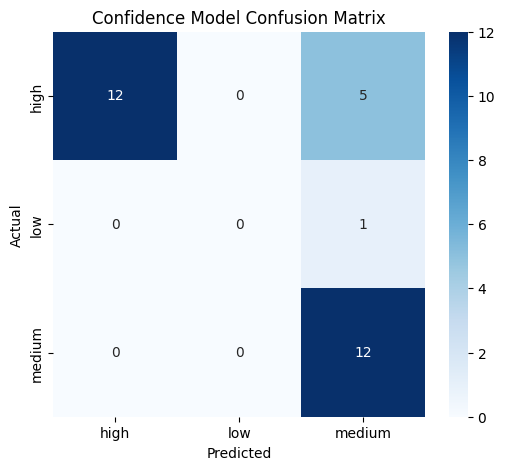

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_conf_test,
    confidence_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=confidence_label_encoder.classes_,
    yticklabels=confidence_label_encoder.classes_
)

plt.title("Confidence Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## 8. Saving artefacts

Saves model and preprocessing artefacts into the folders consumed by the Streamlit prototype.


In [ ]:
# -----------------------------
# Save Confidence Model Components
# -----------------------------

import joblib

joblib.dump(confidence_model, MODELS_DIR / "confidence_model.pkl")
joblib.dump(confidence_scaler, MODELS_DIR / "confidence_scaler.pkl")
joblib.dump(confidence_label_encoder, MODELS_DIR / "confidence_label_encoder.pkl")

print("Confidence model components saved successfully.")


Confidence model components saved successfully.


In [ ]:
# -----------------------------
# Save Simulated Behavioural Dataset
# -----------------------------

behaviour_df.to_csv(DATA_DIR / "simulated_behavioural_confidence_data.csv", index=False)

print("Simulated behavioural dataset saved successfully.")


Simulated behavioural dataset saved successfully.
